<a href="https://colab.research.google.com/github/carlavilla/DataViz2025/blob/main/CV_PS3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Exploring factors that may impact Philadelphia's PIT count
**Definition of Homelessness as per [HUD](https://www.hudexchange.info/homelessness-assistance/coc-esg-virtual-binders/coc-esg-homeless-eligibility/four-categories/category-1/)** <br>
Individual or family who lacks a fixed, regular, and adequate nighttime residence, meaning:

1. Has a primary nighttime residence that is a public or private place not meant for human habitation; or
2. Is living in a publicly or privately operated shelter designated to provide temporary living arrangements (including congregate shelters, transitional housing, and hotels and motels paid for by charitable organizations or by federal, state and local government programs); or
3. Is exiting an institution where (s)he has resided for 90 days or less and who resided in an emergency shelter or place not meant for human habitation immediately before entering that institution.

**Background:** <br>
[1](https://www.phila.gov/2022-12-15-the-2023-pit-count-is-coming-what-it-is-why-its-important-and-how-you-can-help/#:~:text=The%20U.S.%20Department%20of%20Housing,in%20January%20every%20other%20year.) The Point-In-Time (PIT) Count is a national count of homeless people across the country. The US Department of Housing and Urban Development (HUD) requires that state and local governments receiving federal funding to address homelessness, known as Continuums of Care or CoC, conduct an annual PIT Count in the month of January. <br>
2 The primary purpose of the PIT Count is to count homeless individuals, with a secondary purpose of collecting demographic information about homeless households (e.g. age, ethnicity, time homeless). There has been criticism about the accuracy of the PIT count. The survey tool is developed by HUD and deployed by each CoC. HUD does **not** require every counted individual to be surveyed. <br>
3  There have been criticisms about the accuracy of the PIT count. Most issues point to discrepancies across data collection methods and conditions outside of the protocol scope that may impact the number of individuals that get counted. Examples include number of counters, weather, hidden sheltering spaces (e.g. cars, abandoned structures), and criminalization of homelessness-adjacent activities.

**Research questions:**
* What variables within the current data collection methods of the PIT count appear to impact the accuracy of the count?
* What variables outside of the data collection methods appear to impact the accuracy of the count?

#Environment set up

In [ ]:
#setting up basic libraries
import time, os, sys, re
import zipfile, json, datetime, string
import numpy as np
from statistics import *
import matplotlib.pyplot as plt
import pandas as pd
import pandas_datareader as pdr
from pandas_datareader import wb
from pandas.io.formats.style import Styler

In [ ]:
#setting up link to online data and Colab
import urllib
from google.colab import files
import seaborn as sns
from google.colab import data_table
data_table.enable_dataframe_formatter()

#Retrieving Data Sets

##Dataset 1: PIT Unsheltered Count
**Description:** Overall count of homeless individuals at PIT counts in Philadelphia, available 2007 to 2023. A subcount of unsheltered homeless individuals included. <br>
**Relevance:** Dependent variable. Overall count and subcount of unsheltered homeless individuals is expected to change in line with other variables. <br>
**Retrieved from:** Downloaded from [HUD PIT and HIC Data reservoir](https://www.hudexchange.info/resource/3031/pit-and-hic-data-since-2007/) on 2/5/2025.<br>
**Format:** .xlsb dataset that allows creation of a subtable. <br>
**Format for analyses:** Subtable was extracted for PA-500 CoC (Philadelphia) as an xlsx file. Data transposed on Excel.

####Dataset Prep (pit)

In [ ]:
urllib.request.urlretrieve("https://drive.google.com/uc?id=1Rt9o407BcPjRLF2qzJljDHXqjLjWH0kj&export=download", "HUDPIT_PA500_2007to2023.xlsx")

('HUDPIT_PA500_2007to2023.xlsx', <http.client.HTTPMessage at 0x7d160f9ed590>)

In [ ]:
pit = pd.read_excel('HUDPIT_PA500_2007to2023.xlsx', sheet_name= 'PA500_total')

In [ ]:
#checking headers and setting
pit.columns

Index(['year', 'total_count', 'Unsheltered'], dtype='object')

In [ ]:
#Renaming for consistency and merging
pit = pit.rename(columns={'year': 'Year'})
pit.columns

Index(['Year', 'total_count', 'Unsheltered'], dtype='object')

In [ ]:
print(f'Median={pit.total_count.median()}')
print(f'Min={pit.total_count.min()}')
print(f'Max={pit.total_count.max()}')

Median=3343.5
Min=2871
Max=5191


In [ ]:
print(f'Median={pit.Unsheltered.median()}')
print(f'Min={pit.Unsheltered.min()}')
print(f'Max={pit.Unsheltered.max()}')

Median=685.0
Min=361
Max=1083


####PIT Count visualization

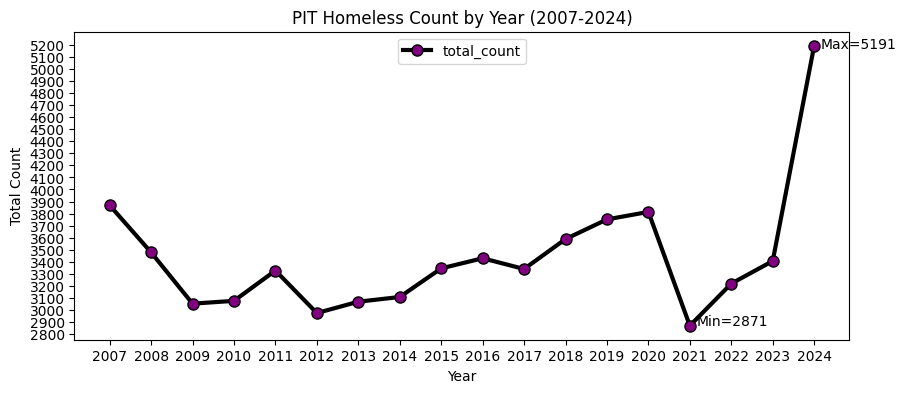

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot( 'Year', 'total_count', data=pit, marker='o', markerfacecolor='purple', markersize=8, color='black', linewidth=3)
ax.legend(loc='upper center')
ax.set_yticks([2800, 2900, 3000, 3100, 3200, 3300, 3400, 3500, 3600, 3700, 3800, 3900, 4000, 4100, 4200, 4300, 4400, 4500, 4600, 4700, 4800, 4900, 5000, 5100, 5200])
ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

#medpit=pit.total_count.median()
minpit=pit.total_count.min()
maxpit=pit.total_count.max()
# Find the year corresponding to the median value
#median_year = pit.loc[pit['total_count'] == medpit, 'Year'].iloc[0]
minpit_year = pit.loc[pit['total_count'] == minpit, 'Year'].iloc[0]
maxpit_year = pit.loc[pit['total_count'] == maxpit, 'Year'].iloc[0]
# Annotate using the median year and median value
ax.annotate(f'Median={medpit}', (median_year, medpit),fontsize=10, xytext=(10, -10), textcoords='offset points')
ax.annotate(f'Min={minpit}', (minpit_year, minpit),fontsize=10, xytext=(5, 0), textcoords='offset points')
ax.annotate(f'Max={maxpit}', (maxpit_year, maxpit),fontsize=10, xytext=(5, -2), textcoords='offset points')

plt.xlabel('Year')
plt.ylabel('Total Count')
plt.title('PIT Homeless Count by Year (2007-2024)');

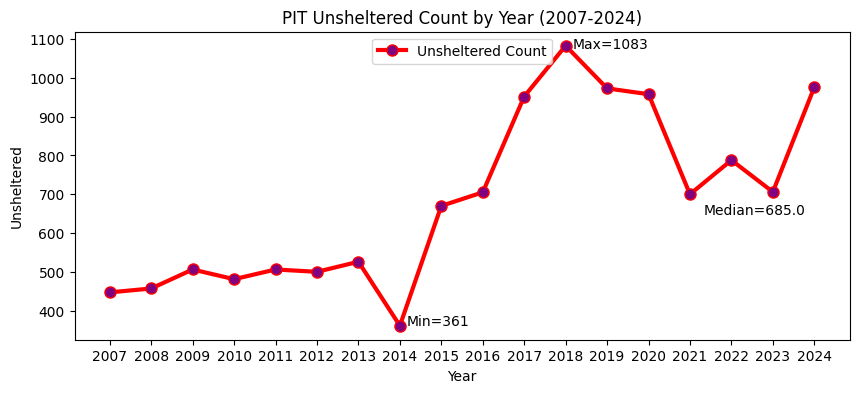

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot( 'Year', 'Unsheltered', data=pit, marker='o', markerfacecolor='purple', markersize=8, color='red', linewidth=3, label="Unsheltered Count")
ax.legend(loc='upper center')
#ax.set_yticks([2800, 2900, 3000, 3100, 3200, 3300, 3400, 3500, 3600, 3700, 3800, 3900])
ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

medpit=pit.Unsheltered.median()
minpit=pit.Unsheltered.min()
maxpit=pit.Unsheltered.max()
# Find the year corresponding to the median value
#median_year = pit.loc[pit['Unsheltered'] == medpit, 'Year'].iloc[0]
minpit_year = pit.loc[pit['Unsheltered'] == minpit, 'Year'].iloc[0]
maxpit_year = pit.loc[pit['Unsheltered'] == maxpit, 'Year'].iloc[0]
# Annotate using the median year and median value
ax.annotate(f'Median={medpit}', (median_year, medpit),fontsize=10, xytext=(10, -10), textcoords='offset points')
ax.annotate(f'Min={minpit}', (minpit_year, minpit),fontsize=10, xytext=(5, 0), textcoords='offset points')
ax.annotate(f'Max={maxpit}', (maxpit_year, maxpit),fontsize=10, xytext=(5, -2), textcoords='offset points')

plt.xlabel('Year')
plt.ylabel('Unsheltered')
plt.title('PIT Unsheltered Count by Year (2007-2024)');

##Dataset 2: Temperature
**Description:** Mean for minimum temperature in Fahrenheit per month 2007-2023. <br>
**Relevance:** Independent variable. Lower temperatures may force unsheltered homeless people to seek out formal shelter and informal shelter (e.g. public transit, someone's couch) thus reducing overall count. <br>
**Retrieved from:** Downloaded from the [National Weather Service](https://www.weather.gov/wrh/Climate?wfo=phi) on 2/12/2025.<br>
**Format:** data table generated within webpage, available for printing or download as pdf only. <br>
**Format for analyses:** Attempted to read pdf for analyses but could not figure out this time. Ended up converting the pdf to an .xlsx file on Adobe Acrobat. Cleaning of headers on Excel.

####Dataset prep (tempJan)

In [ ]:
#retrieving .xlsx document converted on Adobe Acrobat, cleaned on Excel
urllib.request.urlretrieve("https://drive.google.com/uc?id=1myHP4UxOXomqz5JSAYJyo5L3R5v-KW_b&export=download", "min_temp_2007to2023.xlsx")
tempx=pd.read_excel('min_temp_2007to2023.xlsx')

In [ ]:
tempx.columns

Index(['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
       'Oct', 'Nov', 'Dec', 'Annual'],
      dtype='object')

In [ ]:
tempJan= tempx[['Year','Jan']]

In [ ]:
tempJan= tempJan.rename(columns={'Jan': 'Temp'})
tempJan.columns

Index(['Year', 'Temp'], dtype='object')

####Dataset visual (tempJan)

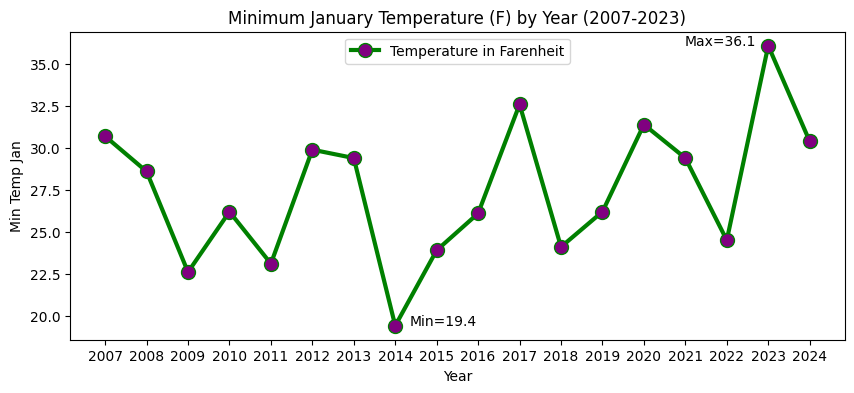

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot('Year', 'Temp', data=tempJan, marker='o', markerfacecolor='purple', markersize=10, color='green', linewidth=3, label= 'Temperature in Farenheit')
ax.legend(loc='upper center')
ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

#medtemp=tempJan.Temp.median()
mintemp=tempJan.Temp.min()
maxtemp=tempJan.Temp.max()
# Find the year corresponding to the median value
#mediantemp_year = tempJan.loc[tempJan['Temp'] == medtemp, 'Year'].iloc[0]
mintemp_year = tempJan.loc[tempJan['Temp'] == mintemp, 'Year'].iloc[0]
maxtemp_year = tempJan.loc[tempJan['Temp'] == maxtemp, 'Year'].iloc[0]
# Annotate using the median year and median value
#ax.annotate(f'Median={medtemp}', (mediantemp_year, medtemp),fontsize=10, xytext=(-20, 8), textcoords='offset points')
ax.annotate(f'Min={mintemp}', (mintemp_year, mintemp),fontsize=10, xytext=(10, 0), textcoords='offset points')
ax.annotate(f'Max={maxtemp}', (maxtemp_year, maxtemp),fontsize=10, xytext=(-60, 0), textcoords='offset points')

plt.xlabel('Year')
plt.ylabel('Min Temp Jan')
plt.title('Minimum January Temperature (F) by Year (2007-2023)');

##Dataset 3: Precipitation
**Description:** Mean precipitation in inches for each month 2007-2024. <br>
**Relevance:** Independent variable. Higher precipitation may force homeless people to seek out last-resort informal shelter, reducing overall count. <br>
**Retrieved from:** Downloaded from the [National Weather Service](https://www.weather.gov/wrh/Climate?wfo=phi) on 2/12/2025.<br>
**Format:** data table generated within webpage, available for printing or download as pdf only. <br>
**Format for analyses:** Converted the pdf to an .xlsx file on Adobe Acrobat. Attempting cleaning here.

####Dataset prep (precip5)

In [ ]:
#true headers at Index 1, first column not valid
urllib.request.urlretrieve("https://drive.google.com/uc?id=1vm5e50vTZJoyGvA75OtmboqdpHtNWtHA&export=download", "mean_precip_2007to2023.xlsx")
precip = pd.read_excel('mean_precip_2007to2023.xlsx')
precip.head(3)
#you can tell python where the header stars- find command to designate header

,"2/13/25, 12:49 AM about:blank",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,NaN,Monthly Mean Precipitation for Philadelphia A...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
2,NaN,2007,0.11,0.06,0.12,0.3,0.09,0.13,0.11,0.09,0.02,0.15,0.05,0.14,0.11


In [ ]:
#only need data for each year, do not need Index 20 to 24
precip.tail(7)

,"2/13/25, 12:49 AM about:blank",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
18,NaN,2023,0.11,0.05,0.06,0.17,0.01,0.14,0.17,0.1,0.2,0.02,0.09,0.26,0.12
19,NaN,2024,0.19,0.05,0.23,0.14,0.06,0.16,0.08,0.16,0.03,T,0.08,0.11,0.11
20,NaN,Mean,0.1,0.11,0.12,0.13,0.11,0.15,0.15,0.17,0.14,0.11,0.09,0.15,0.13
21,NaN,Max,0.19,0.22,0.24,0.3,0.21,0.35,0.43,0.62,0.34,0.19,0.3,0.29,0.18
22,NaN,NaN,2024,2018,2010,2007,2016,2013,2013,2011,2011,2022,2018,2009,NaN
23,NaN,Min,0.05,0.03,0.03,0.06,0.01,0.06,0.05,0.03,0.02,T,0.02,0.04,0.1
24,NaN,NaN,2021,2009,2012,2016,2023,2017,2012,2015,2007,2024,2021,2017,NaN


In [ ]:
precip2= precip.rename(columns={'Unnamed: 1': 'Year', 'Unnamed: 2': 'Precip'})
precip2.head()

,"2/13/25, 12:49 AM about:blank",Year,Precip,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,NaN,Monthly Mean Precipitation for Philadelphia A...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
2,NaN,2007,0.11,0.06,0.12,0.3,0.09,0.13,0.11,0.09,0.02,0.15,0.05,0.14,0.11
3,NaN,2008,0.06,0.14,0.12,0.07,0.15,0.1,0.11,0.08,0.14,0.05,0.13,0.18,0.11
4,NaN,2009,0.09,0.03,0.05,0.13,0.16,0.16,0.11,0.33,0.12,0.18,0.07,0.29,0.14


In [ ]:
#removing irrelevant data
precip3= precip2[['Year', 'Precip']]
precip3.head()


,Year,Precip
0,Monthly Mean Precipitation for Philadelphia A...,NaN
1,Year,Jan
2,2007,0.11
3,2008,0.06
4,2009,0.09


In [ ]:
#removing extraneous rows
precip4 = precip3.drop(precip3.index[0:2])
precip4.head()

,Year,Precip
2,2007,0.11
3,2008,0.06
4,2009,0.09
5,2010,0.07
6,2011,0.11


In [ ]:
#checking index for tail
precip4.tail(7)

,Year,Precip
18,2023,0.11
19,2024,0.19
20,Mean,0.1
21,Max,0.19
22,NaN,2024
23,Min,0.05
24,NaN,2021


In [ ]:
#reseting index so I can delete the correct indeces
precip_reset= precip4.reset_index(drop=True)
precip_reset.tail(7)

,Year,Precip
16,2023,0.11
17,2024,0.19
18,Mean,0.1
19,Max,0.19
20,NaN,2024
21,Min,0.05
22,NaN,2021


In [ ]:
#dropping extraneous tail indices
precip5= precip_reset.drop(precip_reset.index[18:])
precip5.tail()

,Year,Precip
13,2020,0.09
14,2021,0.05
15,2022,0.11
16,2023,0.11
17,2024,0.19


In [ ]:
precip5.head()

,Year,Precip
0,2007,0.11
1,2008,0.06
2,2009,0.09
3,2010,0.07
4,2011,0.11


####Dataset prep (precip5)

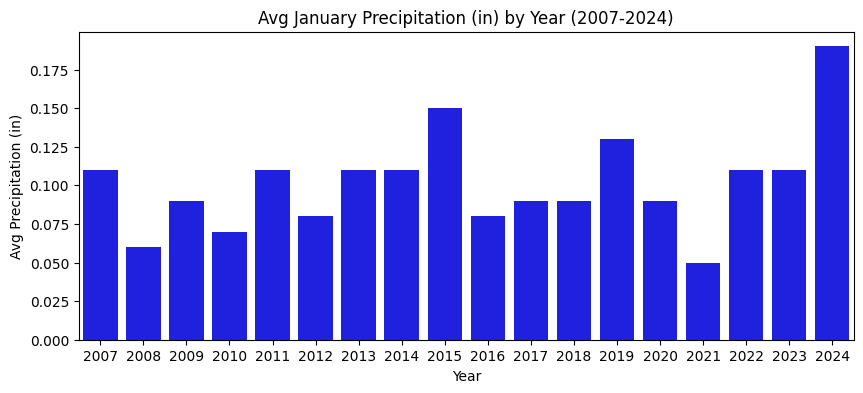

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
ax = sns.barplot(x="Year", y="Precip", data=precip5, estimator=np.mean, errorbar=('ci', 95), capsize=.1, color='blue')
plt.xlabel('Year')
plt.ylabel('Avg Precipitation (in)')
plt.title('Avg January Precipitation (in) by Year (2007-2024)');

##Dataset 4: Demolitions
**Description:** Number of property demolitions initiated in Philadelphia 2007 to 2025. <br>
**Relevance:** Demolition of empty structures may result in fewer informal shelter opportunities for homeless folk, resulting in more visible homeless people during the count in January. <br>
**Retrieved from:** Downloaded from [Open Data Philly](https://opendataphilly.org/datasets/building-demolitions/) on 2/12/2025. <br>
**Format:** csv available on website for download <br>
**Format for analyses:** Demolitions are listed by address so there are multiple entries per year. Created a new sheet and used the Excel CountIf function to count demolitions for each calendar year. Since the demolitions for a given year (e.g. 2007) would hypothetically impact the count in January of the following year (e.g. 2008), a second column was created on Excel as "pit year" to indicate the year the data coulw be relevant for. Since .csv docs do now allow multiple sheets, the spreadsheet was saved as a .xlsx


####Dataset prep (demo3)

In [ ]:
import pandas as pd
urllib.request.urlretrieve("https://drive.google.com/uc?id=1i_Uc-gNSdaHFVDcaCbX4o2CN04EvNEx7&export=download", "demolitions_2007to2025.xlsx")
demo=pd.read_excel('demolitions_2007to2025.xlsx', sheet_name='Sheet1')

In [ ]:
demo.columns

Index(['year', 'year pit', 'Demolition count'], dtype='object')

In [ ]:
demo2 = demo.drop(columns=['year'])
demo2.columns

Index(['year pit', 'Demolition count'], dtype='object')

In [ ]:
#renaming year column to prep for merging
#QUESTION: Why do I have to create a new dataframe here whereas I didn't to do that for renaming it in the pit dataframe?
demo3=demo2.rename(columns={'year pit': 'Year'})
demo3.columns

Index(['Year', 'Demolition count'], dtype='object')

In [ ]:
demo3=demo3.rename(columns={'Demolition count': 'demos'})
demo3.columns

Index(['Year', 'demos'], dtype='object')

####Dataset visual (demo3)

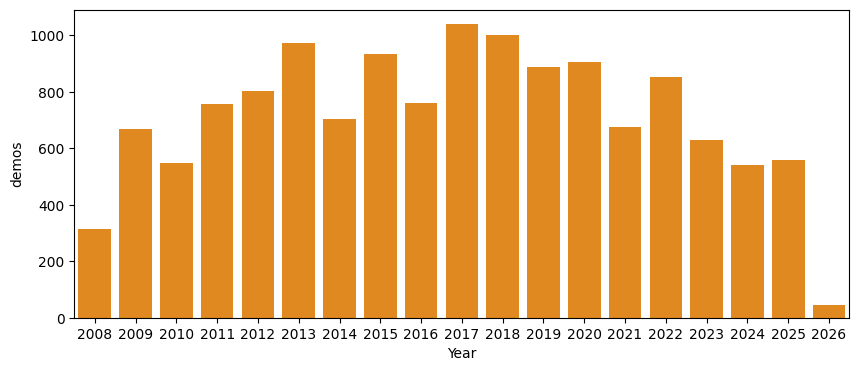

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
ax = sns.barplot(x="Year", y="demos", data=demo3, estimator=np.mean, errorbar=('ci', 95), capsize=.1, color='darkorange')

meddem=demo3.demos.median()
mindem=demo3.demos.min()
maxdem=demo3.demos.max()
meddem_year = demo3.loc[demo3['demos'] == meddem, 'Year'].iloc[0]
mindem_year = demo3.loc[demo3['demos'] == mindem, 'Year'].iloc[0]
maxdem_year = demo3.loc[demo3['demos'] == maxdem, 'Year'].iloc[0]
ax.annotate(f'Median={meddem}', (meddem_year, meddem),fontsize=10, xytext=(5, 0), textcoords='offset points')
ax.annotate(f'Min={mindem}', (mindem_year, mindem),fontsize=10, xytext=(5, 0), textcoords='offset points')
ax.annotate(f'Max={maxdem}', (maxdem_year, maxdem),fontsize=10, xytext=(5, 0), textcoords='offset points');
#ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
               # ha='center', va='center', xytext=(0, 8), textcoords='offset points')


#Merging Datasets


In [ ]:
merged_df = pd.merge(pit, tempJan, on='Year', how='outer', indicator='merged')
merged_df

,Year,total_count,Unsheltered,Temp,merged
0,2007,3869,447,30.7,both
1,2008,3479,457,28.6,both
2,2009,3054,506,22.6,both
3,2010,3077,481,26.2,both
4,2011,3328,506,23.1,both
5,2012,2976,500,29.9,both
6,2013,3070,526,29.4,both
7,2014,3109,361,19.4,both
8,2015,3346,670,23.9,both
9,2016,3430,705,26.1,both


In [ ]:
merged_df['merged'].value_counts()

,count
merged,
both,18
left_only,0
right_only,0


Merge was succesful. No unmerged items as expected.

In [ ]:
merged_df = pd.merge(merged_df, precip5, on='Year', how='outer', indicator='merged2')
merged_df

,Year,total_count,Unsheltered,Temp,merged,Precip,merged2
0,2007,3869,447,30.7,both,0.11,both
1,2008,3479,457,28.6,both,0.06,both
2,2009,3054,506,22.6,both,0.09,both
3,2010,3077,481,26.2,both,0.07,both
4,2011,3328,506,23.1,both,0.11,both
5,2012,2976,500,29.9,both,0.08,both
6,2013,3070,526,29.4,both,0.11,both
7,2014,3109,361,19.4,both,0.11,both
8,2015,3346,670,23.9,both,0.15,both
9,2016,3430,705,26.1,both,0.08,both


In [ ]:
merged_df['merged2'].value_counts()

,count
merged2,
both,18
left_only,0
right_only,0


Merge was successful. No unmerged items as expected.

In [ ]:
pitmerged1= pd.merge(merged_df, demo3, on='Year', how='inner', indicator='merged3')
pitmerged1

,Year,total_count,Unsheltered,Temp,merged,Precip,merged2,demos,merged3
0,2008,3479,457,28.6,both,0.06,both,315,both
1,2009,3054,506,22.6,both,0.09,both,667,both
2,2010,3077,481,26.2,both,0.07,both,548,both
3,2011,3328,506,23.1,both,0.11,both,758,both
4,2012,2976,500,29.9,both,0.08,both,803,both
5,2013,3070,526,29.4,both,0.11,both,974,both
6,2014,3109,361,19.4,both,0.11,both,703,both
7,2015,3346,670,23.9,both,0.15,both,935,both
8,2016,3430,705,26.1,both,0.08,both,762,both
9,2017,3341,952,32.6,both,0.09,both,1039,both


In [ ]:
pitmerged1['merged3'].value_counts()

,count
merged3,
both,17
left_only,0
right_only,0


Merge successful. Removed unmatched items as data for 2025 and 2026 is not relevant in this study.

In [ ]:
pitmerged=pitmerged1[['Year', 'total_count', 'Unsheltered', 'Temp', 'Precip', 'demos']]
pitmerged.columns

Index(['Year', 'total_count', 'Unsheltered', 'Temp', 'Precip', 'demos'], dtype='object')

#Visuals Merged Dataset (pitmerged)

**Goal:** Review frequencies of variables to see general pattern of change overtime for each variable.

Text(0.5, 1.0, 'Total and Unsheltered Count by Year (2007-2024)')

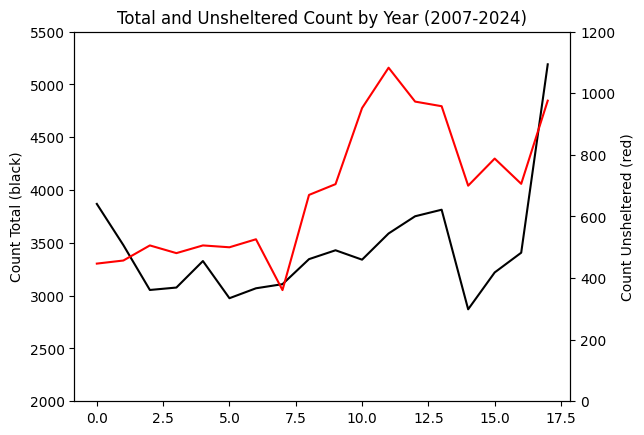

In [ ]:
ax = pit['total_count'].plot(color= 'black',ylim=(2000,5500))
ax2 = pit['Unsheltered'].plot(secondary_y=True,color='red', ylim=(0,1200))
#ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])
ax.set_ylabel('Count Total (black)')
ax2.set_ylabel('Count Unsheltered (red)')
plt.title('Total and Unsheltered Count by Year (2007-2024)')

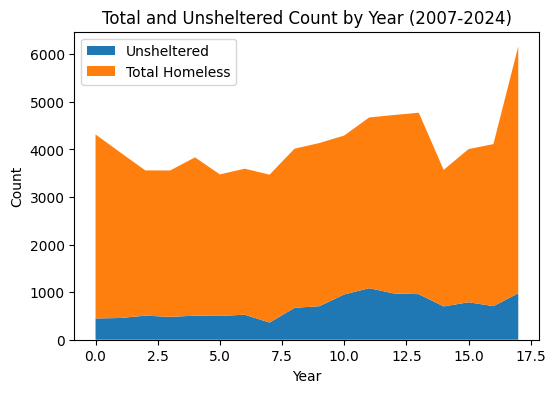

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.stackplot(range(18),pit["Unsheltered"], pit["total_count"],labels=['Unsheltered', 'Total Homeless'])
#ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])
ax.legend(loc='upper left')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Total and Unsheltered Count by Year (2007-2024)');
#ax.margins(2007, 2024)
#ax.title('100 % stacked area chart');

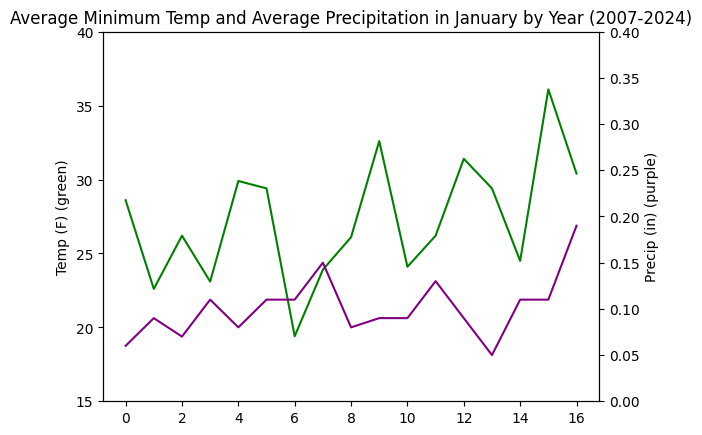

In [ ]:
ax = pitmerged['Temp'].plot(color= 'green',ylim=(15,40))
ax2 = pitmerged['Precip'].plot(secondary_y=True,color='purple', ylim=(0,.4))
#ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])
ax.set_ylabel('Temp (F) (green)')
ax2.set_ylabel('Precip (in) (purple)')
plt.title('Average Minimum Temp and Average Precipitation in January by Year (2007-2024)');

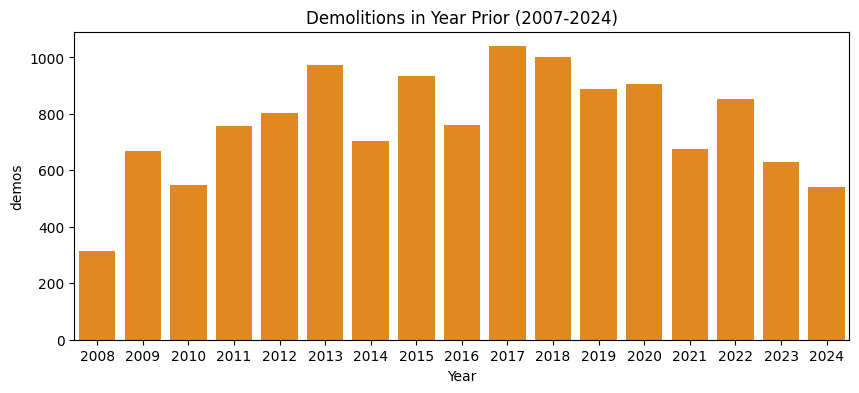

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
ax = sns.barplot(x="Year", y="demos", data=pitmerged, estimator=np.mean, errorbar=('ci', 95), capsize=.1, color='darkorange')
plt.title('Demolitions in Year Prior (2007-2024)');

meddem=pitmerged.demos.median()
mindem=pitmerged.demos.min()
maxdem=pitmerged.demos.max()
meddem_year = pitmerged.loc[pitmerged['demos'] == meddem, 'Year'].iloc[0]
mindem_year = pitmerged.loc[pitmerged['demos'] == mindem, 'Year'].iloc[0]
maxdem_year = pitmerged.loc[pitmerged['demos'] == maxdem, 'Year'].iloc[0]
ax.annotate(f'Median={meddem}', xy=(meddem_year, meddem),fontsize=10, xytext=(5, 0), textcoords='offset points')
ax.annotate(f'Min={mindem}', xy=(mindem_year, mindem),fontsize=10, xytext=(5, 0), textcoords='offset points')
ax.annotate(f'Max={maxdem}', xy=(maxdem_year, maxdem),fontsize=10, xytext=(5, 0), textcoords='offset points');
#ax.annotate(f'Median={meddem}, Min={mindem}, Max= {maxdem}', ha='center', va='center', xytext=(0, 8), textcoords='offset points')

**Interpretation of Visuals:** <br>
*PIT Counts:* The number of unsheltered people makes up a fraction of the total of counted homeless individuals. Overall, both counts follow a similar pattern overtime. <br>
*Temperature and Precipitation:* The average minimum temperature (F) fluctuates from year to year but is seen increasing over time. The average precipitation (in) also fluctuates from year to year but appears to remain within the same range over the years, with a sharp increase in 2024. <br>
*Demolitions:* The number of demolitions appear to fluctuate in the couple hundreds from year to year. The number appears to be consistently high between years 2016-2019 (pictured as impacted year counts in 2017-2020) and to have dropped since. The spike in year 2021 (pictured as impacted year 2022) could reflect a backlog of demolition projects approved in 2021 after the pandemic.


**Goal:** Check for correlations between the dependent and independent variables, as well as potential multicollinearity between independent variables. Multicollinearity would indicate that two independent variables are related, and this could impact how each of these variables' relationship to the PIT counts are interpreted.

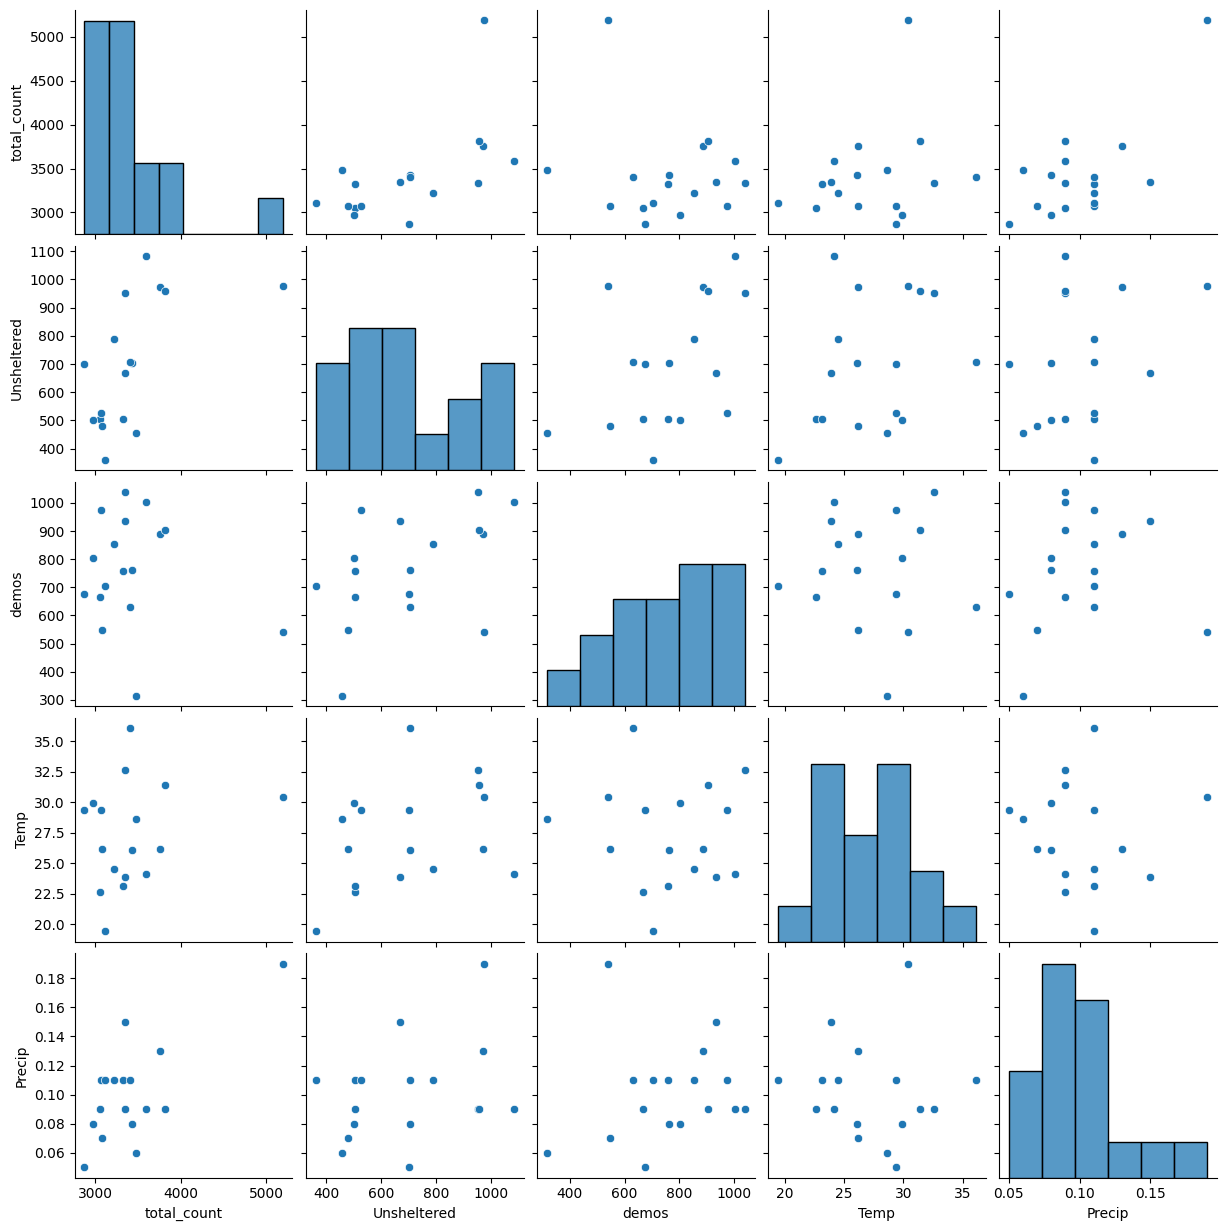

In [ ]:
#corr matrix
sns.pairplot(pitmerged[['total_count', 'Unsheltered', 'demos','Temp','Precip']]) #,height=2,aspect=1

<Axes: >

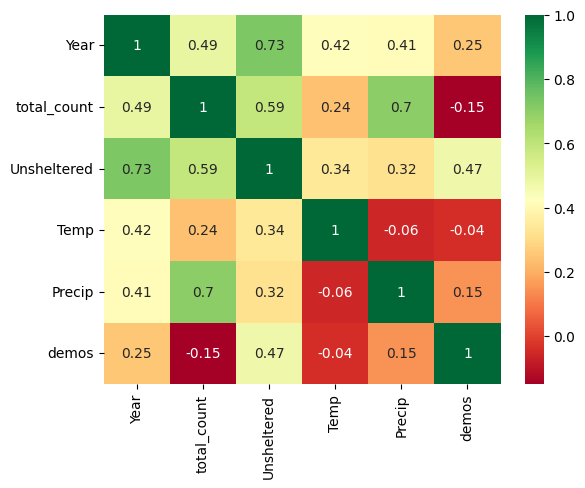

In [ ]:
sns.heatmap(pitmerged.corr().round(2),cmap="RdYlGn",annot=True)

**Scatter Plot Interpretation:** Scatterplots do not suggest any strong correlations between independent variables.<br>
**Correlation Matrix:** The correlation matrix points to some potential correlations of interest, namely:<br>

*   Increasing number of unsheltered people (r=.73) and overall homeless count (r=.49) over time.
*   Increasing temperature (r=.42) and precipitation (r=.41) over time.
* Increasing number of unsheltered people with increasing number of demolitions over the prior year (r=.47).
* Increasing number of unsheltered people with increasing temperatures (r=.34) and precipitation (r=.32).




**Unsheltered Count vs Demolition Number**

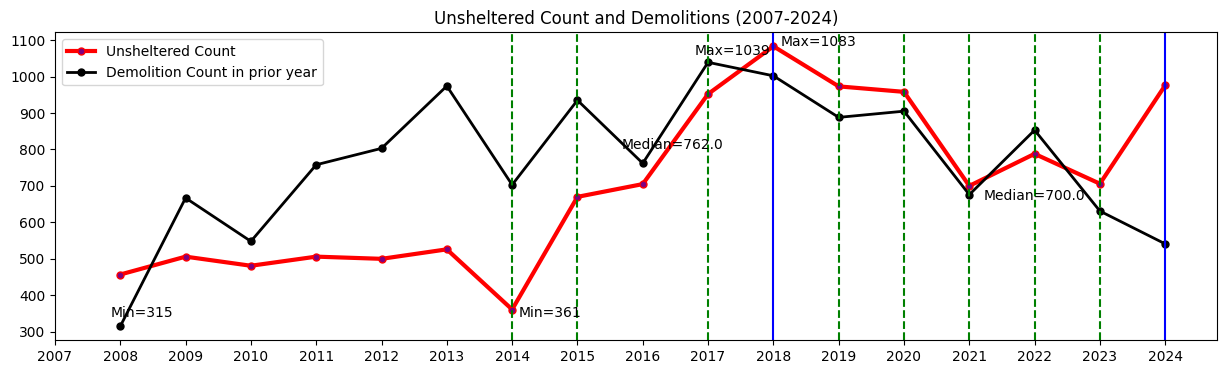

In [ ]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot( 'Year', 'Unsheltered', data=pitmerged, marker='o', markerfacecolor='purple', markersize=5, color='red', linewidth=3, label="Unsheltered Count")
ax.plot( 'Year', 'demos', data=pitmerged, marker='o', markerfacecolor='black', markersize=5, color='black', linewidth=2, label="Demolition Count in prior year")
ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])
plt.title('Unsheltered Count and Demolitions (2007-2024)')
# plot descriptives Pit
medpit=pitmerged.Unsheltered.median()
minpit=pitmerged.Unsheltered.min()
maxpit=pitmerged.Unsheltered.max()
median_year = pitmerged.loc[pitmerged['Unsheltered'] == medpit, 'Year'].iloc[0]
minpit_year = pitmerged.loc[pitmerged['Unsheltered'] == minpit, 'Year'].iloc[0]
maxpit_year = pitmerged.loc[pitmerged['Unsheltered'] == maxpit, 'Year'].iloc[0]
ax.annotate(f'Median={medpit}', (median_year, medpit),fontsize=10, xytext=(10, -10), textcoords='offset points')
ax.annotate(f'Min={minpit}', (minpit_year, minpit),fontsize=10, xytext=(5, -5), textcoords='offset points')
ax.annotate(f'Max={maxpit}', (maxpit_year, maxpit),fontsize=10, xytext=(5, 0), textcoords='offset points')
# plot descriptives demos
meddem=pitmerged.demos.median()
mindem=pitmerged.demos.min()
maxdem=pitmerged.demos.max()
meddem_year = pitmerged.loc[pitmerged['demos'] == meddem, 'Year'].iloc[0]
mindem_year = pitmerged.loc[pitmerged['demos'] == mindem, 'Year'].iloc[0]
maxdem_year = pitmerged.loc[pitmerged['demos'] == maxdem, 'Year'].iloc[0]
ax.annotate(f'Median={meddem}', (meddem_year, meddem),fontsize=10, xytext=(-15, 10), textcoords='offset points')
ax.annotate(f'Min={mindem}', (mindem_year, mindem),fontsize=10, xytext=(-7, 7), textcoords='offset points')
ax.annotate(f'Max={maxdem}', (maxdem_year, maxdem),fontsize=10, xytext=(-10, 5), textcoords='offset points')
#plot visual notes
ax.axvline(2014, color="green", ls="--")
ax.axvline(2015, color="green", ls="--")
ax.axvline(2017, color="green", ls="--")
ax.axvline(2019, color="green", ls="--")
ax.axvline(2020, color="green", ls="--")
ax.axvline(2021, color="green", ls="--")
ax.axvline(2022, color="green", ls="--")
ax.axvline(2023, color="green", ls="--")
ax.axvline(2018, color="blue", ls="solid")
ax.axvline(2024, color="blue", ls="solid")
ax.legend();

**Interpretation:** There moderate correlation between the number of Unsheltered homeless people and the number of demolitions in the previous calendar year is reflected in this graph. With the increase of demolition projects, the number of Unsheltered homeless people counted the following January increases for most years. the exception to this pattern are the years 2018 and 2024, which might require a closer look.

**Unsheltered vs Temperature**

In [ ]:
pd.options.mode.copy_on_write = True
pitmerged['shortpit'] = pitmerged['Unsheltered'] / 10

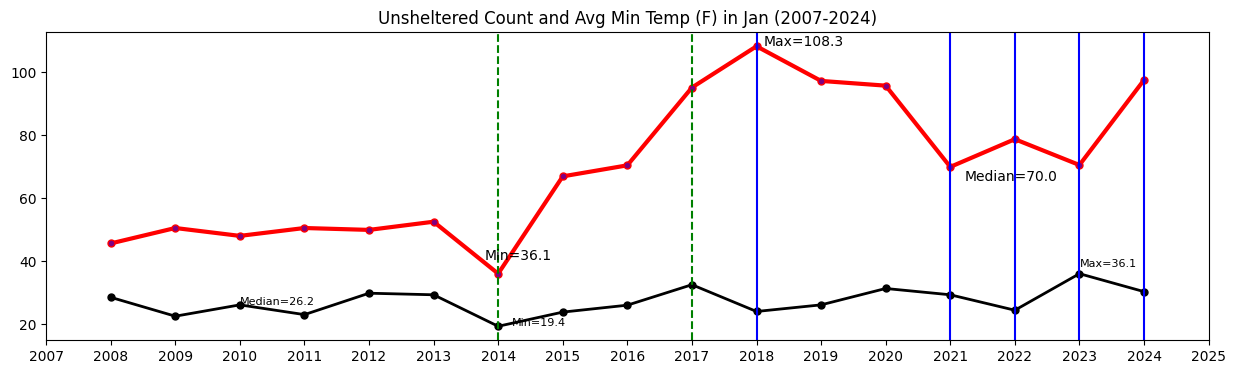

In [ ]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot( 'Year', 'shortpit', data=pitmerged, marker='o', markerfacecolor='purple', markersize=5, color='red', linewidth=3, label="Unsheltered Count")
ax.plot( 'Year', 'Temp', data=pitmerged, marker='o', markerfacecolor='black', markersize=5, color='black', linewidth=2, label="Temp(F)")
ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])
plt.title('Unsheltered Count and Avg Min Temp (F) in Jan (2007-2024)')
# plot descriptives Pit
medpit=pitmerged.shortpit.median()
minpit=pitmerged.shortpit.min()
maxpit=pitmerged.shortpit.max()
median_year = pitmerged.loc[pitmerged['shortpit'] == medpit, 'Year'].iloc[0]
minpit_year = pitmerged.loc[pitmerged['shortpit'] == minpit, 'Year'].iloc[0]
maxpit_year = pitmerged.loc[pitmerged['shortpit'] == maxpit, 'Year'].iloc[0]
ax.annotate(f'Median={medpit}', (median_year, medpit),fontsize=10, xytext=(10, -10), textcoords='offset points')
ax.annotate(f'Min={minpit}', (minpit_year, minpit),fontsize=10, xytext=(-10, 10), textcoords='offset points')
ax.annotate(f'Max={maxpit}', (maxpit_year, maxpit),fontsize=10, xytext=(5, 0), textcoords='offset points')
# plot descriptives Temp
medtemp=pitmerged.Temp.median()
mintemp=pitmerged.Temp.min()
maxtemp=pitmerged.Temp.max()
mediantemp_year = pitmerged.loc[pitmerged['Temp'] == medtemp, 'Year'].iloc[0]
mintemp_year = pitmerged.loc[pitmerged['Temp'] == mintemp, 'Year'].iloc[0]
maxtemp_year = pitmerged.loc[pitmerged['Temp'] == maxtemp, 'Year'].iloc[0]
ax.annotate(f'Median={medtemp}', (mediantemp_year, medtemp),fontsize=8, xytext=(0, 0), textcoords='offset points')
ax.annotate(f'Min={mintemp}', (mintemp_year, mintemp),fontsize=8, xytext=(10, 0), textcoords='offset points')
ax.annotate(f'Max={maxtemp}', (maxtemp_year, maxtemp),fontsize=8, xytext=(0, 5), textcoords='offset points')
#plot visual notes
ax.axvline(2014, color="green", ls="--")
ax.axvline(2017, color="green", ls="--")
ax.axvline(2018, color="blue", ls="solid")
ax.axvline(2021, color="blue", ls="solid")
ax.axvline(2022, color="blue", ls="solid")
ax.axvline(2023, color="blue", ls="solid")
ax.axvline(2024, color="blue", ls="solid")

**Interpretation:** The weak-moderate correlation between the number of Unsheltered homeless people and average minimum temperature in January (r=0.34) is shown in this graph. From years 2008-2013, both the Unsheltered homeless count and the average minimum January temperature remain consistent. There are some years in which we see that an increase or decrease in temperature aligns with a corresponding increase or decrease in the unsheltered count (e.g. 2014, 2017). However, this pattern is switched in later years, which may also require a closer look.

**Unsheltered Count vs Precipitation**

In [ ]:
pd.options.mode.copy_on_write = True
pitmerged['bigprecip'] = pitmerged['Precip'] * 100

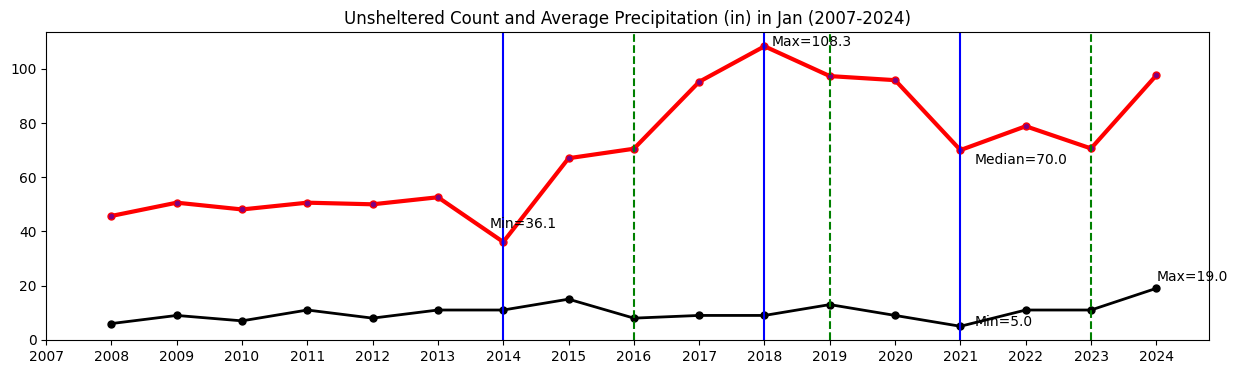

In [ ]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot( 'Year', 'shortpit', data=pitmerged, marker='o', markerfacecolor='purple', markersize=5, color='red', linewidth=3, label="Unsheltered Count")
ax.plot( 'Year', 'bigprecip', data=pitmerged, marker='o', markerfacecolor='black', markersize=5, color='black', linewidth=2, label="Precipitation (in)")
plt.title('Unsheltered Count and Average Precipitation (in) in Jan (2007-2024)')
ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])
# plot descriptives Pit
medpit=pitmerged.shortpit.median()
minpit=pitmerged.shortpit.min()
maxpit=pitmerged.shortpit.max()
median_year = pitmerged.loc[pitmerged['shortpit'] == medpit, 'Year'].iloc[0]
minpit_year = pitmerged.loc[pitmerged['shortpit'] == minpit, 'Year'].iloc[0]
maxpit_year = pitmerged.loc[pitmerged['shortpit'] == maxpit, 'Year'].iloc[0]
ax.annotate(f'Median={medpit}', (median_year, medpit),fontsize=10, xytext=(10, -10), textcoords='offset points')
ax.annotate(f'Min={minpit}', (minpit_year, minpit),fontsize=10, xytext=(-10, 10), textcoords='offset points')
ax.annotate(f'Max={maxpit}', (maxpit_year, maxpit),fontsize=10, xytext=(5, 0), textcoords='offset points')
# plot descriptives Precipitation
#medpre=pitmerged.bigprecip.median()
minpre=pitmerged.bigprecip.min()
maxpre=pitmerged.bigprecip.max()
#medpre_year = pitmerged.loc[pitmerged['bigprecip'] == medpre, 'Year'].iloc[0]
minpre_year = pitmerged.loc[pitmerged['bigprecip'] == minpre, 'Year'].iloc[0]
maxpre_year = pitmerged.loc[pitmerged['bigprecip'] == maxpre, 'Year'].iloc[0]
#ax.annotate(f'Median={medpre}', (medpre_year, medpre),fontsize=10, xytext=(0, 0), textcoords='offset points')
ax.annotate(f'Min={minpre}', (minpre_year, minpre),fontsize=10, xytext=(10, 0), textcoords='offset points')
ax.annotate(f'Max={maxpre}', (maxpre_year, maxpre),fontsize=10, xytext=(0, 5), textcoords='offset points')
#plot visual notes
ax.axvline(2016, color="green", ls="--")
ax.axvline(2019, color="green", ls="--")
ax.axvline(2023, color="green", ls="--")
ax.axvline(2014, color="blue", ls="solid")
ax.axvline(2018, color="blue", ls="solid")
ax.axvline(2021, color="blue", ls="solid")

**Interpretation:** The weak-moderate correlation between the number of Unsheltered homeless people and average precipitation in January (r=0.32) is shown in this graph. From years 2008-2013, both the Unsheltered homeless count and the average precipitation in January remain consistent. There are some years in which we see that an increase or decrease in temperature aligns with a corresponding decrease or increase in the unsheltered count (e.g. 2016, 2019). However, other years of big changes in the unsheltered population do not align with changes in precipitation (e.g. 2014, 2018, 2021).